# practice lab : Linear Regression

# 1 - Import packages
- [numpy](https://www.numpy.org) is the fundamental package for working with matrices in Python.
- [matplotlib](https://matplotlib.org) is a famous library to plot graphs in Python.
- [pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) is used for data manipulation and analysis (in this lab used it to load the dataset)
  

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import copy

## 2 -  Problem Statement


Suppose you are the CEO of a restaurant franchise and are considering different cities for opening a new outlet.
- You would like to expand your business to cities that may give your restaurant higher profits.
- The chain already has restaurants in various cities and you have data for profits and populations from the cities.
- You also have data on cities that are candidates for a new restaurant. 
    - For these cities, you have the city population.

Can you use the data to help you identify which cities may potentially give your business higher profits?


## 3 - Dataset

You will start by loading the dataset for this task or create a dataset . 
  - `x_train` is the population of a city
  - `y_train` is the profit of a restaurant in that city. A negative value for profit indicates a loss.   

In [15]:
df= pd.read_csv(r"E:\SALEH\Data\ex1data1.txt",names= ['population','profit'])

In [16]:
df.head()

,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [17]:
X_train = df['population']
X_train = np.array(X_train)

print(f"The shape of X_train : {X_train.shape}")
print(f"Number of training EX : {len(X_train)}")
print(f"First five element of X_train : {X_train[:5]}")


The shape of X_train : (97,)
Number of training EX : 97
First five element of X_train : [6.1101 5.5277 8.5186 7.0032 5.8598]


`x_train` is a numpy array that contains decimal values that are all greater than zero.
- These values represent the city population times 10,000
- For example, 6.1101 means that the population for that city is 61,101
  
Now, let's print `y_train`

In [18]:
y_train = df['profit']
y_train = np.array(y_train)


print(f"The shape of y_train : {y_train.shape}")
print(f"Number of training EX : {len(y_train)}")
print(f"First five element of y_train : {y_train[:5]}")

The shape of y_train : (97,)
Number of training EX : 97
First five element of y_train : [17.592   9.1302 13.662  11.854   6.8233]


Similarly, `y_train` is a numpy array that has decimal values, some negative, some positive.
- These represent your restaurant's average monthly profits in each city, in units of \$10,000.
  - For example, 17.592 represents \$175,920 in average monthly profits for that city.
  - -2.6807 represents -\$26,807 in average monthly loss for that city.

#### Visualize your data

It is often useful to understand the data by visualizing it. 
- For this dataset, you can use a scatter plot to visualize the data, since it has only two properties to plot (profit and population). 
- Many other problems that you will encounter in real life have more than two properties (for example, population, average household income, monthly profits, monthly sales).When you have more than two properties, you can still use a scatter plot to see the relationship between each pair of properties.


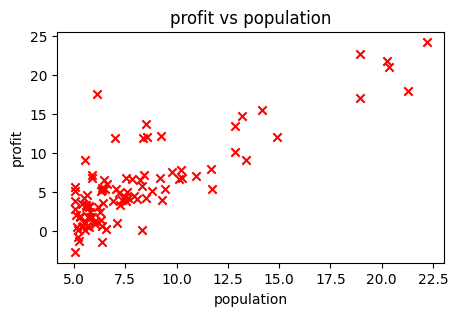

In [19]:
for label in df.columns[:-1]:
    plt.figure(figsize=(5, 3))
    plt.scatter(df[label], df["profit"],c = "red",marker= "x")
    plt.title(f"profit vs {label}")
    plt.xlabel(label)
    plt.ylabel("profit")
    plt.show()

our goal is to build a linear regression model to fit this data.
- With this model, you can then input a new city's population, and have the model estimate your restaurant's potential monthly profits for that city.

---
# linear regression
- The model function for linear regression, which is a function that maps from `x` (city population) to `y` (your restaurant's monthly profit for that city) is represented as 
    $$f_{w,b}(x) = wx + b$$

- To train a linear regression model, you want to find the best $(w,b)$ parameters that fit your dataset.  

    - To compare how one choice of $(w,b)$ is better or worse than another choice, you can evaluate it with a cost function $J(w,b)$
      - $J$ is a function of $(w,b)$. That is, the value of the cost $J(w,b)$ depends on the value of $(w,b)$.
      - The choice of $(w,b)$ that fits your data the best is the one that has the smallest cost $J(w,b)$.
     

- To find the values $(w,b)$ that gets the smallest possible cost $J(w,b)$, you can use a method called **gradient descent**. 
  - With each step of gradient descent, your parameters $(w,b)$ come closer to the optimal values that will achieve the lowest cost $J(w,b)$.


 
- The trained linear regression model can then take the input feature $x$ (city population) and output a prediction $f_{w,b}(x)$ (predicted monthly profit for a restaurant in that city).


## 5 - Compute Cost

Gradient descent involves repeated steps to adjust the value of your parameter $(w,b)$ to gradually get a smaller and smaller cost $J(w,b)$.
- At each step of gradient descent, it will be helpful for you to monitor your progress by computing the cost $J(w,b)$ as $(w,b)$ gets updated. 
- In this section, you will implement a function to calculate $J(w,b)$ so that you can check the progress of your gradient descent implementation.

#### Cost function
As you may recall from the lecture, for one variable, the cost function for linear regression $J(w,b)$ is defined as

$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$ 

- You can think of $f_{w,b}(x^{(i)})$ as the model's prediction of your restaurant's profit, as opposed to $y^{(i)}$, which is the actual profit that is recorded in the data.
- $m$ is the number of training examples in the dataset

#### Model prediction

- For linear regression with one variable, the prediction of the model $f_{w,b}$ for an example $x^{(i)}$ is representented as:

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b$$

This is the equation for a line, with an intercept $b$ and a slope $w$

#### Implementation :

In [20]:
def cost_fun(x,y,w,b):

    m = x.shape[0]
    cost = 0.0

    for i in range(m):
        j_wb_i = x[i] * w + b  #for 1d and x  1d w,b scalar  (in this lab we using this)
        
        #j_wb_i = np.dot(x[i],w) + b   """ for x 2d and w is a vector """

        cost+= (j_wb_i - y[i] )**2

    cost = cost/(2*m)
    return cost

In [21]:
initial_w = 2
initial_b = 1

cost = cost_fun(X_train,y_train,initial_w,initial_b)

print(f"The initial cost = {cost:.3f}")

The initial cost = 75.203



## 6 - Gradient descent 

In this section, you will implement the gradient for parameters $w, b$ for linear regression. 

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & \phantom {0000} b := b -  \alpha \frac{\partial J(w,b)}{\partial b} \newline       \; & \phantom {0000} w := w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{1}  \; & 
\newline & \rbrace\end{align*}$$

where, parameters $w, b$ are both updated simultaniously and where  
$$
\frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{2}
$$
$$
\frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} \tag{3}
$$
* m is the number of training examples in the dataset

    
*  $f_{w,b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$, is the target value


You will implement a function called `compute_gradient` which calculates $\frac{\partial J(w)}{\partial w}$, $\frac{\partial J(w)}{\partial b}$ 

In [22]:
def compute_gradient(x,y,w,b):

    m = x.shape[0]

    dj_dw = 0 
    dj_db = 0

    for i in range(m):
        error = (x[i] * w + b) - y[i] # compute error

        dj_dw += error * x[i]
        dj_db += error
        
        
    return dj_dw/m , dj_db/m

In [23]:
# zeros initial w,b
initial_w = 0
initial_b = 0

tmp_dj_dw , tmp_dj_db = compute_gradient(X_train,y_train,initial_w,initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639


In [24]:
# non - zeros initial w,b
initial_w = 0.2
initial_b = 0.2

tmp_dj_dw , tmp_dj_db = compute_gradient(X_train,y_train,initial_w,initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -47.41610118114435 -4.007175051546391


--- 
### 2.6 Learning parameters using batch gradient descent

- A good way to verify that gradient descent is working correctly is to look at the value of $J(w,b)$ and check that it is decreasing with each step.

---
Gradient descent update param : 

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$


In [25]:
def gradient_descent(x,y,w_in,b_in,compute_gradient,compute_cost,alpha,num_iter,):

    m = len(x)

    J_history= []
    w_history= []

    w = copy.deepcopy(w_in)
    b= b_in

    for i in range(num_iter):
        # Calculate the gradient 
        dj_dw,dj_db = compute_gradient(x,y,w,b)
        
        # update parameters 
        w = w - alpha *dj_dw
        b = b - alpha *dj_db

        # save the cost fun at each iteration
        if i < 100000 :
            cost = cost_fun(x,y,w,b)
            J_history.append(cost)

        # print the cost function history
        if i % (num_iter // 10) == 0:
            w_history.append(w)
            print(f"Step {i}: Cost = {J_history[-1]:.2f}")

    return w,b,J_history,w_history

    

# Run the gradient descent algorithm

In [26]:
initial_w = 0
initial_b = 0

iterations = 1500
alpha = 0.01

fin_w,fin_b,J_hist,w_hist = gradient_descent(X_train,y_train,initial_w,initial_b,compute_gradient,cost_fun,alpha,iterations)

Step 0: Cost = 6.74
Step 150: Cost = 5.31
Step 300: Cost = 4.96
Step 450: Cost = 4.76
Step 600: Cost = 4.64
Step 750: Cost = 4.57
Step 900: Cost = 4.53
Step 1050: Cost = 4.51
Step 1200: Cost = 4.50
Step 1350: Cost = 4.49


In [27]:
print(f"w,b found by GD : w = {fin_w} b = {fin_b}")

w,b found by GD : w = 1.166362350335582 b = -3.63029143940436


In [28]:
print(f"the cost function before GD {J_hist[0]} the cost fun after GD {J_hist[-1]}")

the cost function before GD 6.737190464870008 the cost fun after GD 4.483388256587726


# prediction vs target 

In [29]:
for i in range(5):
    print(f"prediction: {X_train[i]*fin_w + fin_b} Target : {y_train[i]}")

prediction: 3.4962991573810798 Target : 17.592
prediction: 2.817009724545637 Target : 9.1302
prediction: 6.305482878164328 Target : 13.662
prediction: 4.537977372465788 Target : 11.854
prediction: 3.204358661092083 Target : 6.8233


# viualization

In [30]:
m = X_train.shape[0]
pred = np.zeros(m)

for i in range(m):
    pred[i] = X_train[i] * fin_w + fin_b

Text(0, 0.5, 'profit in 10,000$')

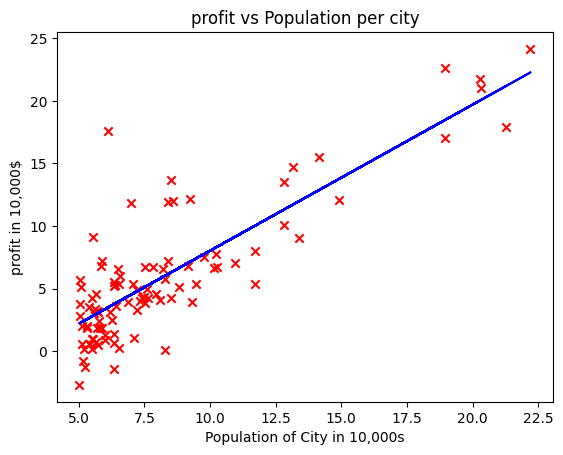

In [31]:
# lineat fit
plt.plot(X_train,pred,c = "blue")

# scatter plot
plt.scatter(X_train,y_train,marker='x',c = 'r')
plt.title("profit vs Population per city")
plt.xlabel("Population of City in 10,000s")
plt.ylabel("profit in 10,000$")

final values of $w,b$ can also be used to make predictions on profits. Let's predict what the profit would be in areas of 35,000 and 70,000 people. 

- The model takes in population of a city in 10,000s as input. 

- Therefore, 35,000 people can be translated into an input to the model as `np.array([3.5])`

- Similarly, 70,000 people can be translated into an input to the model as `np.array([7.])`


In [32]:
predict1 = 3.5 * fin_w + fin_b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * fin_w + fin_b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45
